**Phase Transition in a Random Hierarchy Model**

This project reproduces the phase transition result from Sclocchi et al. (arXiv 2410.13770) using a neural network denoiser. We generate synthetic hierarchical data using the Random Hierarchy Model (RHM) — a tree-structured generative model where tokens at each level are produced from tokens at the level above via randomly sampled production rules. A score network (MLP) is trained to denoise partially masked leaf sequences via cross-entropy loss. We then run forward-backward experiments across noise levels ε, measuring the dynamical susceptibility χ(ε) — a measure of correlations among the tokens changes across the tree. The peak in χ(ε) signals the phase transition where the correlation length diverges and root latent variable becomes unrecoverable.

In [66]:
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict
import itertools
import random

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


**Random Hierrachy Model**

The Random Hierarchy Model (RHM) is a tree-structured generative model of hierarchically structured data. It is defined by the tree depth L (with L+1 levels ranging from L(root) to 0(leaves)), the branching factor s (the number of children each node has), the vocabulary size v (number of distinct symbols per level) and m production rules (which corresponds to the values the children of a node can take). Generation proceeds top-down: the root symbol is sampled uniformly, then each node expands into s children by randomly selecting one of its m pre-assigned production rules. Only the leaf nodes — of which there are s^L — are observed as data. The internal nodes are latent variables that are never directly observed, but whose hierarchical structure induces long-range correlations among the leaves.

In [111]:
# These are the parameters of our model. 

v=10
m=3
s=2
L=4

**Tree generation**

We generate the code for the tree for our case with a function below which returns the leaf nodes. The vocabulary consists of integers from 0 to v*(L+1)-1, partitioned across levels so that symbols at different levels are always distinct. The root level uses integers 0 to v-1, the next level down uses v to 2v-1, and so on down to the leaves. For each node at level l, m production rules are assigned at initialisation by randomly sampling m distinct s-tuples from the child vocabulary at level l-1 without replacement. These rules are fixed before any data is generated. During generation, the root symbol is sampled uniformly, then each node randomly selects one of its m pre-assigned rules to determine its s children, proceeding top-down until the leaves are reached.

In [84]:
def generate_tree(v,m,s,L):
    
    V=[0]*(L+1)

    for level in range(L,-1,-1):
        V[level]= list(range(v*(L-level),v*(L-level+1)))

    dic=defaultdict(list)

    for level in range(L,0,-1):

        product=list(itertools.product(V[level-1],repeat=s))
    
        rand=random.sample(list(range(len(product))),k=len(product))

        i=0
    
        for char in V[level]:

            j=0
            while j<m:
                dic[char].append(product[rand[i]])
                i+=1
                j+=1
   
    tree=[random.choice(V[L])]

    i=0

    length=(1-s**(L))/(1-s)


    while i<length:
        for char in random.choice(dic[tree[i]]):
            tree.append(char)
        i+=1

    return tree[-s**L:]

We create a class to generate noisy data for use with PyTorch's DataLoader. Each time a sample is fetched, a noise level ε is drawn uniformly from [0,1] and applied to the clean sequence by independently masking each token with probability ε — masked tokens are set to -1. The Dataset returns a triple of (noisy sequence, clean sequence, ε) as PyTorch tensors. By sampling ε fresh for every fetch, the network sees all noise levels during training and learns to denoise across the full range simultaneously.

In [86]:
#Creates noisy data and turns them into pytorch tensors
class RHM(Dataset):  

    def __init__(self, samples, v):
        self.samples=samples
        self.v=v

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        
        x_clean=  np.array(self.samples[idx],dtype=np.int32)

        x_masked=x_clean.copy()
    
        epsilon=np.random.uniform(0,1)

        x_masked[np.random.random(len(x_clean))<epsilon] = -1

        return (torch.tensor(x_clean, dtype=torch.long), torch.tensor(x_masked, dtype=torch.long), torch.tensor(epsilon, dtype=torch.float32))


We next one-hot encode the noisy data to feed it to the network. Each token becomes a vector of size v+1 — one slot per leaf vocabulary symbol plus an extra slot for MASK.  

In [88]:
def encode(x_masked,v):

    B, l = x_masked.shape
 
    one_hot = torch.zeros(B, l, v+1, dtype=torch.float32)
    

    x_shifted = x_masked.clone()
    x_shifted[x_masked == -1] = v*L + v
 
    x_shifted = x_shifted - v*L

    one_hot.scatter_(2, x_shifted.unsqueeze(-1), 1.0)
    
    return one_hot.view(B, l*(v+1))

Now lets create an MLP which takes the noisy sequences and predicts the values for the masked tokens. The input is the flattened one-hot encoded sequence concatenated with ε, and the output is a set of logits — one score per vocabulary symbol per position. During training it only gets supervised on masked positions, so it's forced to use the correlations between visible tokens to guess what the hidden ones were. This is how it implicitly learns the hierarchical structure of the RHM. 

In [90]:
#Code for creating a neural network
class Network(nn.Module):

    def __init__(self, seq_len, v, hidden_dims=[256,256]):
        super().__init__()
        self.seq_len=seq_len
        self.v=v

        input_dim = seq_len*(v+1)+1

        layers=[]
        
        for dim in hidden_dims:
            layers+=[nn.Linear(input_dim,dim), nn.ReLU()]
            input_dim=dim

        layers.append(nn.Linear(input_dim, seq_len*(v)))
 
        self.net = nn.Sequential(*layers)

    def forward(self, x_encoded, epsilon):

        out = self.net(torch.cat([x_encoded, epsilon.unsqueeze(1)], dim=1))  
        
        return out.view(-1, self.seq_len, self.v)


Next lets create function which trains the score network using standard mini-batch gradient descent. For each batch, we encode the noisy sequences, run them through the network, and compute cross-entropy loss at the masked positions. For every batch, the network clears the gradients from the previous batch (zero_grad), computes new gradients via backpropagation (backward), and updates the network weights (step). We sample a fresh ε for every sequence in every epoch, so that the network learns to denoise at all noise levels.

In [122]:
def train(model: Network, dataset: RHM, n_epochs: int = 20, batch_size: int = 256, lr: float = 1e-3, device: str = "cpu"):
    
    model = model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
 
    losses = []
    for epoch in range(n_epochs):
        
        model.train()
        
        epoch_loss = 0.0
        n_batches = 0
 
        for x_clean, x_masked, epsilon in loader:
           
            x_masked, x_clean, epsilon = x_masked.to(device), x_clean.to(device), epsilon.to(device)

            logits = model(encode(x_masked, v), epsilon)   
            
            mask = (x_masked == -1) 
 
            if mask.sum() == 0:
                continue  
                
            targets = x_clean - v*L 

            loss = F.cross_entropy(logits[mask], targets[mask])
 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
 
            epoch_loss += loss.item()
            n_batches += 1
 
        avg_loss = epoch_loss / max(n_batches, 1)

        losses.append(avg_loss)
       # print(f"  epoch {epoch+1:3d}/{n_epochs}  loss={avg_loss:.3f}")
 
    return losses

Next we will generate N samples and train the network on the generated samples. We also plot the loss curve obtained from training. 

Training for 1000 epochs...

Final loss: 1.9387


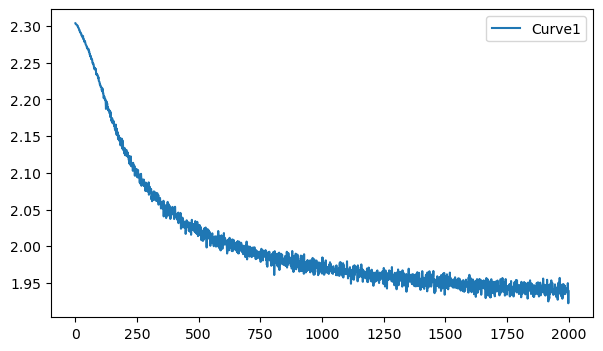

In [129]:
def generate_samples(N,v,m,s,L,seed):


    if seed is not None:
        random.seed(seed)
        
    data=[] 

    for _ in range(N):
        data.append(generate_tree(v,m,s,L)) 

    return data
    
samples=generate_samples(10000,v,m,s,L,None)


dataset=RHM(samples,v)

model = Network(s**L, v, [600,600])

print("Training for 1000 epochs...")
losses = train(model, dataset, n_epochs=2000, batch_size=256, lr=1e-3)

print(f"\nFinal loss: {losses[-1]:.4f}")
#print(f"(Random-chance loss would be log(v_leaf) = {np.log(v):.4f})")

plt.figure(figsize=(7, 4))
plt.plot(losses,label="Curve1")
plt.legend()
plt.show()

We see that across 2000 epochs the loss has saturated to 80% of its initial value. Even though this is not a great reduction in the loss, this will suffice for what we are interested in. 

Here we define a function to run the K forward-backward experiments on a clean sample x0. Each experiment corrupts x0 at a noise level epsilon, passes it through the trained network, reconstructes a new sample xhat by sampling from the predicted distributions. Returns a array of variables sigma[i] = +1 if the token at position i changed, -1 if it stayed the same.

In [133]:
def forward_backward_exp(x0, epsilon, model, K):

    sigma=np.zeros((K,len(x0)))

    model.eval()

    with torch.no_grad():
        
        for k in range(K):

            x_masked=np.array(x0.copy())
            
            x_masked[np.random.random(size=len(x0))<epsilon]=-1

            x_tensor = torch.tensor(x_masked,dtype=torch.long).unsqueeze(0) 
            
            epsilon_tensor= torch.tensor([epsilon], dtype=torch.float32)

            logits = model(encode(x_tensor, v), epsilon_tensor)  
            
            probs = F.softmax(logits[0], dim=-1)  
            
            x_hat = torch.multinomial(probs, num_samples=1).squeeze(-1)  
            
            sigma[k] = np.where(x0 != x_hat.numpy() + v*L, 1, -1)
 
    return sigma

Now lets define a correlation matrix C = ⟨sigma[i] sigma[j]⟩ - ⟨sigma[i]⟩⟨sigma[j]⟩ averaged over K trajectories, which will be used to calculate the susceptibilities.  

In [135]:
def compute_corr(sigma):
    
    K, seq_len = sigma.shape
 
    sigma_mean=[]
    
    mean_sigma = sigma.mean(axis=0)         

    corr=[[] for _ in range(K)]
    
    corr=np.array([np.outer(sigma[i],sigma[i]) for i in range(K)])

    corr_ij = corr.mean(axis=0)
    
    C = corr_ij - np.outer(mean_sigma, mean_sigma)
 
    return C
 

We are now in a position to compute the susceptibility chi as a function of the noise level, averaging over n_samples different starting sequences x0. This is the main experiment — the resulting curve should show a clear peak at εpsilon★, the critical noise level where the root latent variable becomes unrecoverable. Intuitively chi measures the average size of correlated blocks of token changes — it peaks at the phase transition εpsilon★. 

In [137]:
def measure_chi_curve(model, samples,epsilons=None, K=50, n_samples=100):
   
    if epsilons is None:
        epsilons = np.linspace(0.05, 0.95, 20)
 
   
    indices = np.random.choice(len(samples), size=n_samples, replace=False)
    chi_vals = []
    
    for eps in epsilons:
        Corr=None
        
        for idx in indices:
            x0 = samples[idx]
            sigma = forward_backward_exp(x0, eps, model, K)

            C = compute_corr(sigma)
            Corr = C if Corr is None else Corr + C

        Corr/=n_samples

        chi_vals.append(Corr.sum() / np.diag(Corr).sum())
 
    return epsilons, np.array(chi_vals)
 

Finally lets define a function that plots the dynamical susceptibility as a function of the noise. 

In [146]:
def plot_chi(epsilons, chis):
    
    plt.figure(figsize=(7, 4))
    
    plt.plot(epsilons, chis)
    
    plt.xlabel('epsilon ')
    plt.ylabel('chi(epsilon)')
    plt.title('Dynamical susceptibility versus noise')
    #plt.axvline(epsilons[np.argmax(chis)], color='red', linestyle='--',label=f'peak at epsilon*={epsilons[np.argmax(chis)]:.2f}')
   
    plt.tight_layout()
    #plt.savefig('chi_curve.png', dpi=150)
    
    plt.show()
   
    print(f" Peak at epsilon* = {epsilons[np.argmax(chis)]:.2f}")
        
    

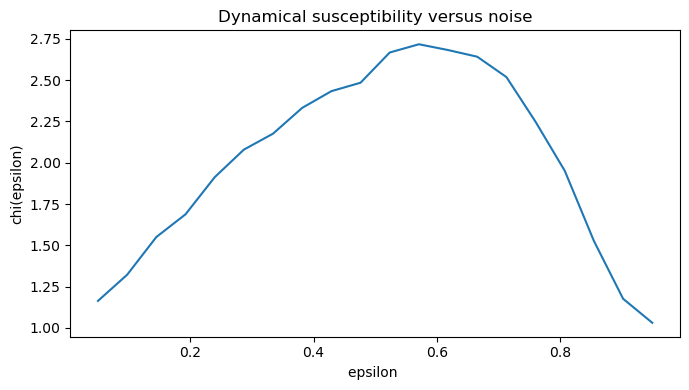

 Peak at epsilon* = 0.57


In [148]:
epsilons, chis=measure_chi_curve(model, samples, epsilons=None, K=60, n_samples=300)
plot_chi(epsilons,chis)

We observe that the susceptibility peaks at εpsilon★ = 0.57, signaling a phase transition consistent with the theoretical predictions of Sclocchi et al. At low noise levels, only shallow latent variables are affected and token changes are largely uncorrelated. As εpsilon increases toward εpsilon★, progressively deeper latent variables begin to flip, inducing large correlated blocks of token changes across the leaf sequence — reflected in the growing susceptibility. At εpsilon★ the root latent variable becomes unrecoverable, marking the point of maximum correlation across the tree. Beyond εpsilon★ the data is too heavily corrupted for the network to reconstruct meaningful structure, and the correlations — along with the susceptibility — decay back toward zero.